In [ ]:
import os
import sys
#print(sys.executable)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import root_scalar
from scipy.integrate import quad
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid
import glob
from matplotlib.ticker import MultipleLocator
from scipy.signal import savgol_filter, find_peaks


In [173]:
Time = {}
CH1 = {}
CH2 = {}


for i in range(0,10):   # 1 ~ 27

    path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek000{i}.xlsx"
    print(os.path.exists(path))
    print("Reading:", path)
    df = pd.read_excel(path, skiprows=20)

    Time[i] = df["TIME"]
    CH1[i] = df["CH1"]
    CH2[i] = df["CH2"]



True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0000.xlsx
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0001.xlsx
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0002.xlsx
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0003.xlsx
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0004.xlsx
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0005.xlsx
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0006.xlsx
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0007.xlsx
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0008.xlsx
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0009.xlsx


0
1
2
3
4
5
6
7


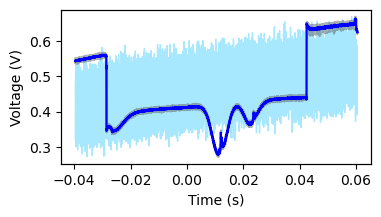

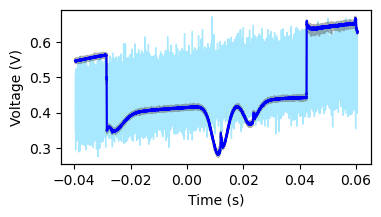

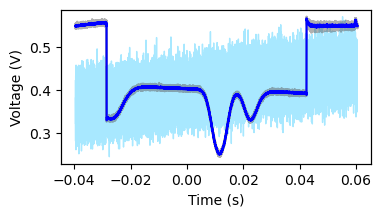

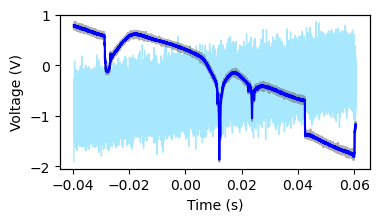

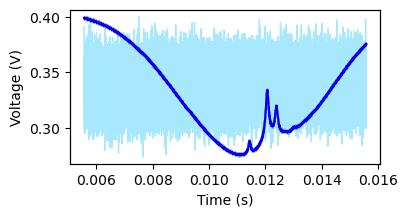

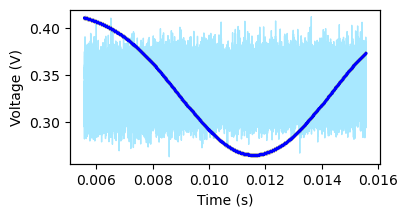

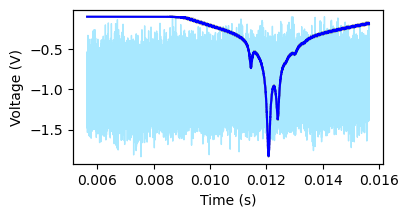

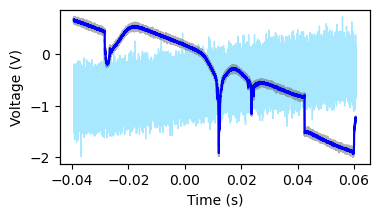

In [255]:

from scipy.signal import savgol_filter

def plot_smoothed_signal(i):
    print(i)
    # ----------------------------
    # Load data
    # ----------------------------
    
    t = Time[i]
    y = CH1[i]
    f = CH2[i]
    # ----------------------------
    # Smoothing only (NO baseline removal)
    # ----------------------------
    # window는 signal 길이에 따라 자동 결정 (너무 세게 안 깎이도록)
    #win = max(21, (len(y) // 200) * 2 + 1)
    win = 31
    y_smooth = savgol_filter(y, win, polyorder=3)

    # ----------------------------
    # Plot
    '''plt.figure(figsize=(4,2)) plt.plot(t, y, color='gray', alpha=0.5) plt.plot(t, y_smooth, color='blue') plt.plot(t, f, color='black') 
    ax1.plot(t, y_smooth, color='blue', zorder=3)'''
    # ----------------------------
    fig, ax1 = plt.subplots(figsize=(4, 2))

# 앞쪽(위쪽)에 그릴 y_smooth
    ax1.plot(t, y, color="#626262", alpha=0.5)
    ax1.plot(t, y_smooth, color='blue', zorder=3)
    
# 뒤쪽에 그릴 f
    ax2 = ax1.twinx()

# f 라인을 ax1 뒤로 보내기
    ax2.set_zorder(ax1.get_zorder() - 1)
    ax1.patch.set_alpha(0)   # ax1 배경 투명하게 해서 뒤가 보이도록


# f 플롯
    ax2.plot(t, f, color="#a8e8ff", lw = 1)

# 오른쪽 y축은 테두리만 남기고 눈금/라벨 제거
    ax2.set_yticks([])
    ax2.set_ylabel('')
    ax2.tick_params(right=False)

# 왼쪽 y축은 정상 유지
    ax1.spines['left'].set_visible(True)

    ax1.set_ylabel("Voltage (V)")
    ax1.set_xlabel("Time (s)")
    #plt.title(f"Smoothing only (no baseline removal) - {i}")
    #plt.xlabel("Time (s)")
    #plt.ylabel("Voltage (V)")
   


# 예시 실행
for i in range(0,8):
    #path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek000{i}.xlsx"
    plot_smoothed_signal(i)



In [175]:

for i in range(10,30):   # 1 ~ 27
    print(i)
    path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek00{i}.xlsx"
    print(os.path.exists(path))
    #print("Reading:", path)
    df = pd.read_excel(path, skiprows=20)

    Time[i] = df["TIME"]
    CH1[i] = df["CH1"]
    CH2[i] = df["CH2"]

10
True
11
True
12
True
13
True
14
True
15
True
16
True
17
True
18
True
19
True
20
True
21
True
22
True
23
True
24
True
25
True
26
True
27
True
28
True
29
True


In [176]:
for i in range(30,44):   # 1 ~ 27
    print(i)
    path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek00{i}.xlsx"
    print(os.path.exists(path))
    #print("Reading:", path)
    df = pd.read_excel(path, skiprows=20)

    Time[i] = df["TIME"]
    CH1[i] = df["CH1"]
    CH2[i] = df["CH2"]

30
True
31
True
32
True
33
True
34
True
35
True
36
True
37
True
38
True
39
True
40
True
41
True
42
True
43
True


In [177]:
'''for i in range(44,87):  
    print(i)
    path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek00{i}.xlsx"
    print(os.path.exists(path))
    #print("Reading:", path)
    df = pd.read_excel(path, skiprows=20)
    Time[i] = df["TIME"]
    CH1[i] = df["CH1"]
    CH2[i] = df["CH2"]'''

'for i in range(44,87):  \n    print(i)\n    path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek00{i}.xlsx"\n    print(os.path.exists(path))\n    #print("Reading:", path)\n    df = pd.read_excel(path, skiprows=20)\n    Time[i] = df["TIME"]\n    CH1[i] = df["CH1"]\n    CH2[i] = df["CH2"]'

In [178]:
Time2 = {}
CH2_1 = {}
CH2_2 = {}

path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek20000.xlsx"
df = pd.read_excel(path, skiprows=20)
print(os.path.exists(path))
Time2[0] = df["TIME"]
CH2_1[0] = df["CH1"]

for i in range(1,8):  
    print(i)
    path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek2000{i}.xlsx"
    print(os.path.exists(path))
    #print("Reading:", path)
    df = pd.read_excel(path, skiprows=20)

    Time2[i] = df["TIME"]
    CH2_1[i] = df["CH1"]
    CH2_2[i] = df["CH2"]



True
1
True
2
True
3
True
4
True
5
True
6
True
7
True


17
18
19
20
21
22
23
24


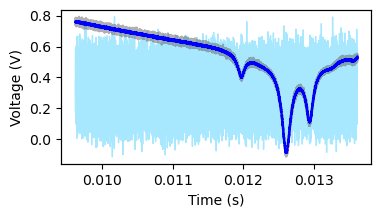

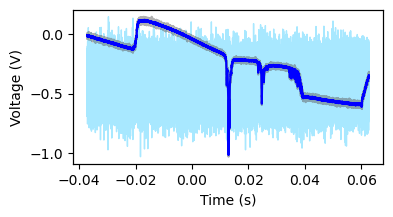

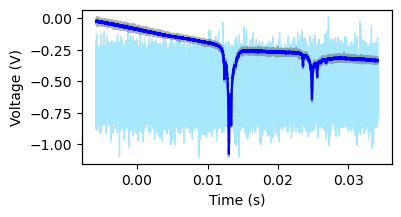

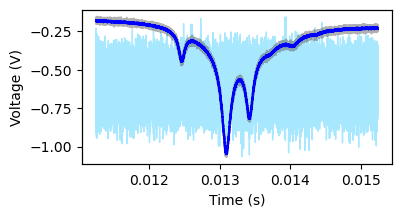

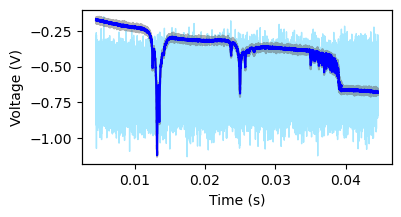

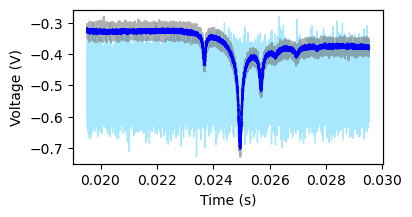

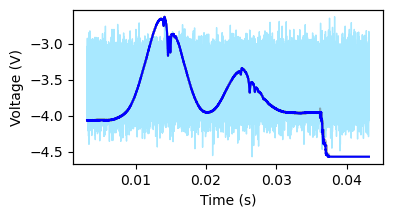

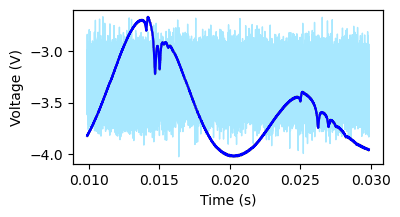

In [179]:
for i in range(17,25):
    plot_smoothed_signal(i)

30
31
32
33
34
35
36
37
38
39
40
41
42
43


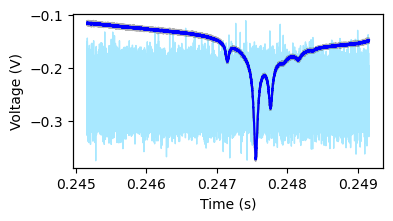

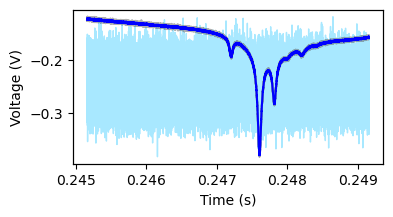

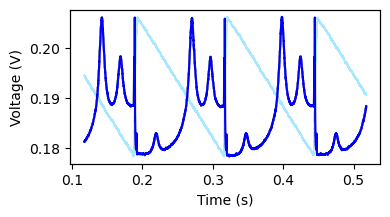

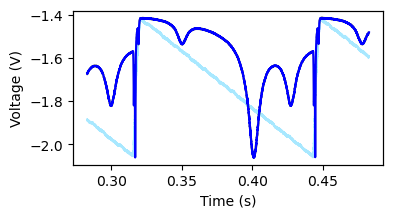

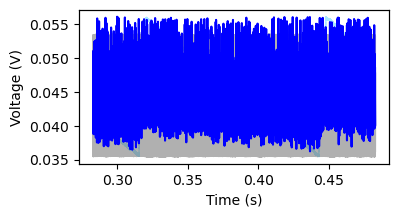

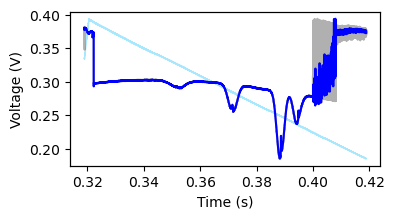

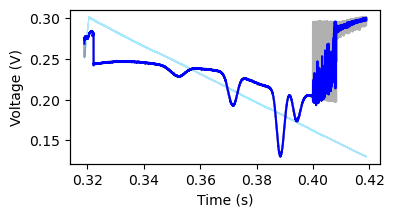

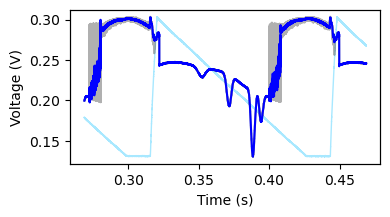

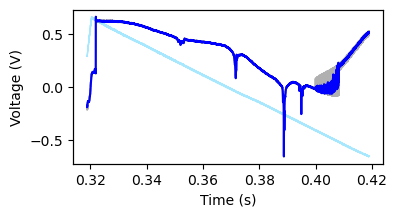

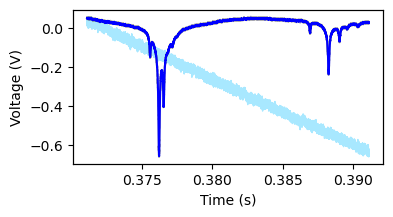

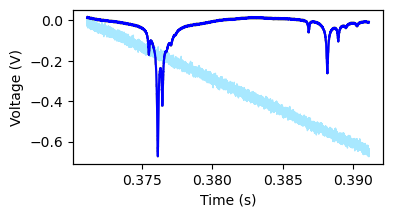

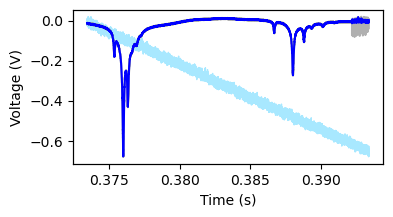

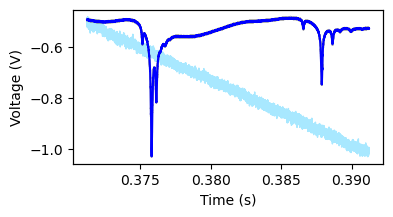

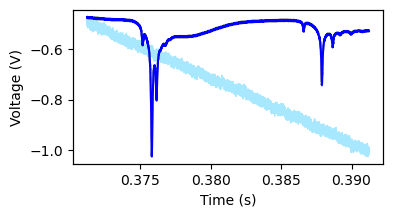

In [180]:
for i in range(30,44):
    plot_smoothed_signal(i)

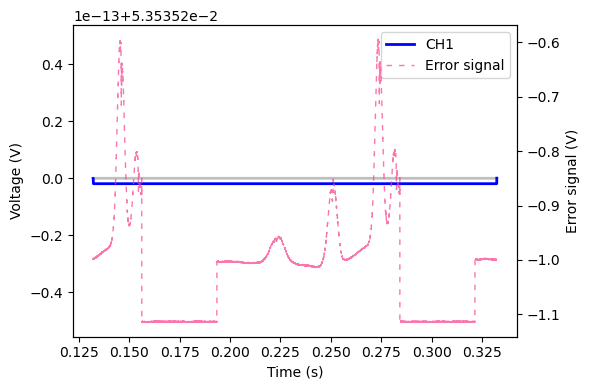

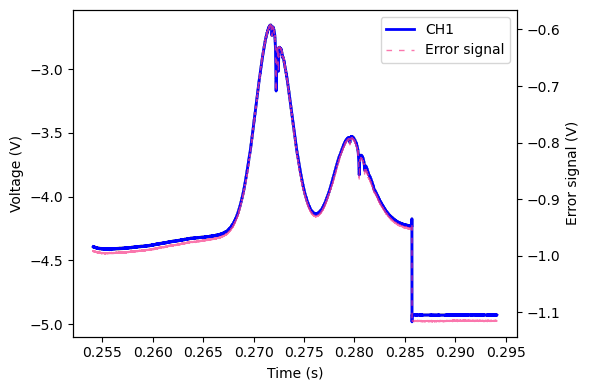

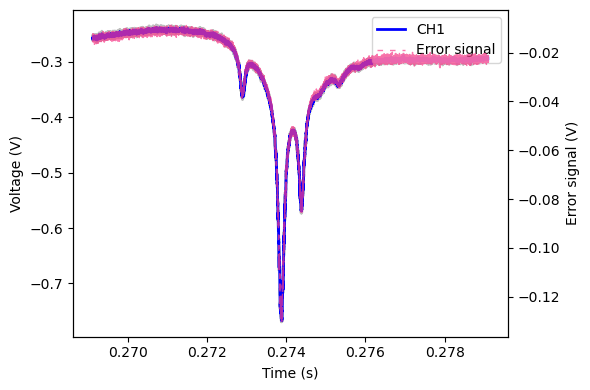

In [234]:
def plot_smoothed_signal2(i):

    # ----------------------------
    # 데이터 존재 여부 체크
    # ----------------------------
    if i not in CH2_1:
        print(f"[skip] CH2_1[{i}] 없음")
        return
    if i not in Time2:
        print(f"[skip] Time2[{i}] 없음")
        return

    y = CH2_1[i]
    t = Time2[i]

    # f는 없어도 plot 가능하므로 optional
    f = CH2_2[i] if i in CH2_2 else None

    # ----------------------------
    # smoothing
    # ----------------------------
    if y is None or len(y) < 7:
        print(f"[skip] signal too short for smoothing: {i}")
        return

    win = 31
    if win >= len(y):
        win = len(y) - 1 if len(y) % 2 == 0 else len(y)

    y_smooth = savgol_filter(y, win, polyorder=3)

    # ----------------------------
    # plot
    # ----------------------------
    plt.figure(figsize=(5,4))

    # Raw
    if y is not None and len(y) > 0:
        plt.plot(t, y, color='gray', alpha=0.5)

    # Smooth
    if y_smooth is not None and len(y_smooth) > 0:
        plt.plot(t, y_smooth, color='blue')

    # CH2_2
    if f is not None and len(f) > 0:
        plt.plot(t, f, color='black')

    plt.xlabel("Time (s)")
    plt.ylabel("Voltage (V)")
    plt.tight_layout()
def plot_smoothed_signal3(i):

    if i not in CH2_1 or i not in Time2:
        print(f"[skip] missing data {i}")
        return

    y = CH2_1[i]
    t = Time2[i]
    f = CH2_2[i] if i in CH2_2 else None

    if y is None or len(y) < 7:
        print(f"[skip] too short {i}")
        return

    win = 31
    if win >= len(y):
        win = len(y) - 1 if len(y) % 2 == 0 else len(y)

    y_smooth = savgol_filter(y, win, polyorder=3)

    fig, ax1 = plt.subplots(figsize=(6,4))
    ax2 = ax1.twinx()

    # ----------------------------
    # Error signal (뒤, dashed)
    # ----------------------------
    if f is not None:
        line_err, = ax2.plot(
            t, f,
            color="#f93d8b",
            alpha=0.7,
            zorder=1,
            linestyle='dashed',
            dashes=(4, 5),
            lw=1,
            label='Error signal'
        )

    # ----------------------------
    # Raw + Smooth (앞)
    # ----------------------------
    ax1.plot(t, y, color='gray', alpha=0.5, zorder=3, lw=2)  # raw (legend 제외)

    line_smooth, = ax1.plot(
        t, y_smooth,
        color='blue',
        zorder=4,
        lw=2,
        label='CH1'
    )

    ax1.set_ylabel("Voltage (V)")
    ax2.set_ylabel("Error signal (V)")
    ax1.set_xlabel("Time (s)")

    # ----------------------------
    # 범례 하나로 합치기
    # ----------------------------
    lines = [line_smooth]
    labels = ["CH1"]

    if f is not None:
        lines.append(line_err)
        labels.append("Error signal")

    ax1.legend(lines, labels, loc='upper right')

    plt.tight_layout()
    plt.show()
for i in [3,4,7]:
    plot_smoothed_signal3(i)

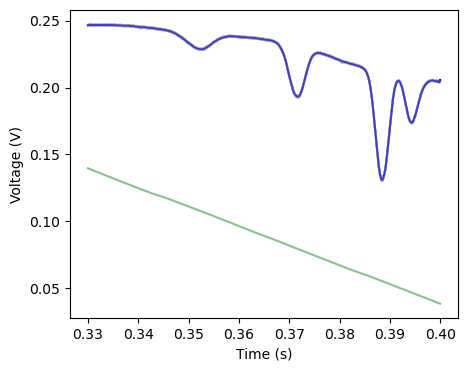

In [216]:
def load_and_smooth(i):
    t = Time[i].values 
    y = CH1[i].values 
    f = CH2[i].values
    win = max(31, (len(y) // 200) * 2 + 1)
    y_smooth = savgol_filter(y, win, polyorder=3)
    f_smooth = savgol_filter(f, win, polyorder=3)
    return t, y, y_smooth,f, f_smooth

t, y, y_smooth,f, f_smooth = load_and_smooth(36)

t_min = 0.33
t_max = 0.4



mask = (t >= t_min) & (t <= t_max)

t_sel = t[mask]
y_sel = y_smooth[mask]
raw_sel = y[mask]
f_sel = f_smooth[mask]
plt.figure(figsize=(5,4))
plt.plot(t_sel,y_sel, color = 'blue')
plt.plot(t_sel, raw_sel, color='grey', alpha=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.plot(t_sel,f_sel*0.09, color ="#89c18d" ) #print((f_smooth[-1]-f_smooth[0])/(t[-1]-t[0]))


Text(0.5, 0, 'Time (s)')

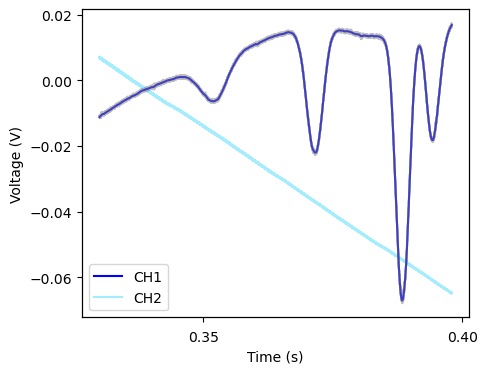

In [244]:
t, y, y_smooth,f, f_smooth = load_and_smooth(36)

t_min = 0.33
t_max = 0.398



mask = (t >= t_min) & (t <= t_max)

t_sel = t[mask]
y_sel = y_smooth[mask]
raw_sel = y[mask]
f_sel = f[mask]
# 선택구간에서만 baseline 피팅
coef = np.polyfit(t_sel, raw_sel, deg=1)
baseline_sel = np.polyval(coef, t_sel)

# baseline 제거
raw_corr = raw_sel - baseline_sel
y_corr = y_sel - baseline_sel

# 플롯
'''
plt.plot(t_sel, y_corr, color='blue')
plt.plot(t_sel, raw_corr, color='grey', alpha=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.plot(t_sel,f_sel*0.005, color ="#89c18d" ) #print((f_smooth[-1]-f_smooth[0])/(t[-1]-t[0]))
'''
fig, ax1 = plt.subplots(figsize=(5,4))
# x축 눈금 간격 널널하게
ax1.xaxis.set_major_locator(MultipleLocator(0.05))
ax1.tick_params(axis='x', labelsize=10, pad=6) #pad는 축과 숫자 간격

# ax1
ax1.plot(t_sel, y_corr, color='blue', label ="CH1")
ax1.plot(t_sel, raw_corr, color='grey', alpha=0.5, label="_nolegend_")

# ax2
ax2 = ax1.twinx()
ax2.set_zorder(ax1.get_zorder() - 1)
ax1.patch.set_alpha(0)

ax2.plot(t_sel,f_sel*0.55, color ="#ffffff" , lw = 0.1, label="_nolegend_")
ax2.plot(t_sel,f_sel*0.5,  color ="#a3edff", label ="CH2")
ax2.plot(t_sel,f_sel*0.45, color ="#ffffff" , lw = 0.1, label="_nolegend_")

# 🔥 label 있는 것만 legend
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend([l for l in lines if l.get_label() != "_nolegend_"],
           [l.get_label() for l in lines if l.get_label() != "_nolegend_"],
           loc='lower left')

# 오른쪽 y축은 테두리만 남기고 눈금/라벨 제거
ax2.set_yticks([])
ax2.set_ylabel('')
ax2.tick_params(right=False)

# 왼쪽 y축은 정상 유지
ax1.spines['left'].set_visible(True)


ax1.set_ylabel("Voltage (V)")
ax1.set_xlabel("Time (s)")

Text(0.5, 0, 'Time (s)')

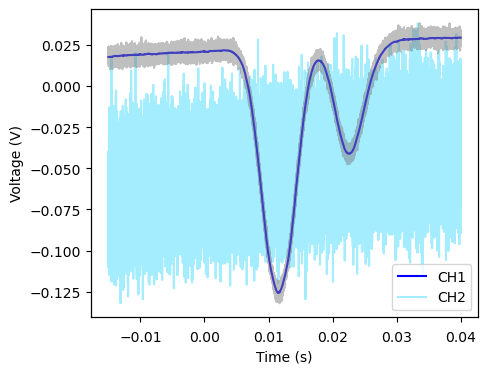

In [245]:
t, y, y_smooth,f, f_smooth = load_and_smooth(2)

t_min = -0.015
t_max = 0.04



mask = (t >= t_min) & (t <= t_max)

t_sel = t[mask]
y_sel = y_smooth[mask]
raw_sel = y[mask]
f_sel = f[mask]
# 선택구간에서만 baseline 피팅
coef = np.polyfit(t_sel, raw_sel, deg=1)
baseline_sel = np.polyval(coef, t_sel)

# baseline 제거
raw_corr = raw_sel - baseline_sel
y_corr = y_sel - baseline_sel

# 플롯
'''
plt.plot(t_sel, y_corr, color='blue')
plt.plot(t_sel, raw_corr, color='grey', alpha=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.plot(t_sel,f_sel*0.005, color ="#89c18d" ) #print((f_smooth[-1]-f_smooth[0])/(t[-1]-t[0]))
'''
fig, ax1 = plt.subplots(figsize=(5,4))
# x축 눈금 간격 널널하게
ax1.xaxis.set_major_locator(MultipleLocator(0.01))
ax1.tick_params(axis='x', labelsize=10, pad=6) #pad는 축과 숫자 간격


# ax1
ax1.plot(t_sel, y_corr, color='blue', label ="CH1")
ax1.plot(t_sel, raw_corr, color='grey', alpha=0.5, label="_nolegend_")

# ax2
ax2 = ax1.twinx()
ax2.set_zorder(ax1.get_zorder() - 1)
ax1.patch.set_alpha(0)

ax2.plot(t_sel,f_sel*0.5,  color ="#a3edff", label ="CH2")

'''ax2.plot(t_sel,f_sel, color ="#ffffff" , lw = 0.1, label="_nolegend_")
ax2.plot(t_sel,f_sel*0.5,  color ="#a3edff", label ="CH2")
ax2.plot(t_sel,f_sel*0.05, color ="#ffffff" , lw = 0.1, label="_nolegend_")
'''
# 🔥 label 있는 것만 legend
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend([l for l in lines if l.get_label() != "_nolegend_"],
           [l.get_label() for l in lines if l.get_label() != "_nolegend_"],
           loc='lower right')

# 오른쪽 y축은 테두리만 남기고 눈금/라벨 제거
ax2.set_yticks([])
ax2.set_ylabel('')
ax2.tick_params(right=False)

# 왼쪽 y축은 정상 유지
ax1.spines['left'].set_visible(True)


ax1.set_ylabel("Voltage (V)")
ax1.set_xlabel("Time (s)")

Text(0.5, 0, 'Time (s)')

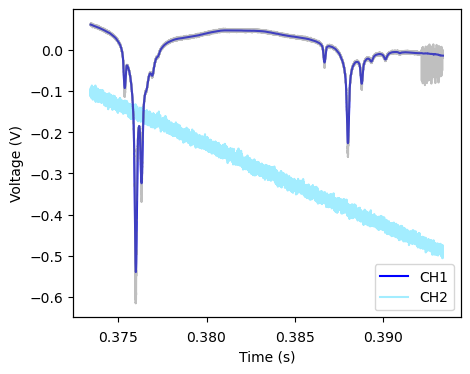

In [246]:
t, y, y_smooth,f, f_smooth = load_and_smooth(41)

t_min = 0
t_max = 1



mask = (t >= t_min) & (t <= t_max)

t_sel = t[mask]
y_sel = y_smooth[mask]
raw_sel = y[mask]
f_sel = f[mask]
# 선택구간에서만 baseline 피팅
coef = np.polyfit(t_sel, raw_sel, deg=1)
baseline_sel = np.polyval(coef, t_sel)

# baseline 제거
raw_corr = raw_sel - baseline_sel
y_corr = y_sel - baseline_sel

# 플롯
'''
plt.plot(t_sel, y_corr, color='blue')
plt.plot(t_sel, raw_corr, color='grey', alpha=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.plot(t_sel,f_sel*0.005, color ="#89c18d" ) #print((f_smooth[-1]-f_smooth[0])/(t[-1]-t[0]))
'''
fig, ax1 = plt.subplots(figsize=(5,4))
# x축 눈금 간격 널널하게
ax1.xaxis.set_major_locator(MultipleLocator(0.005))
ax1.tick_params(axis='x', labelsize=10, pad=6) #pad는 축과 숫자 간격

# ax1
ax1.plot(t_sel, y_corr, color='blue', label ="CH1")
ax1.plot(t_sel, raw_corr, color='grey', alpha=0.5, label="_nolegend_")

# ax2
ax2 = ax1.twinx()
ax2.set_zorder(ax1.get_zorder() - 1)
ax1.patch.set_alpha(0)

ax2.plot(t_sel,f_sel*0.55, color ="#ffffff" , lw = 0.1, label="_nolegend_")
ax2.plot(t_sel,f_sel*0.5,  color ="#a3edff", label ="CH2")
ax2.plot(t_sel,f_sel*0.45, color ="#ffffff" , lw = 0.1, label="_nolegend_")

# 🔥 label 있는 것만 legend
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend([l for l in lines if l.get_label() != "_nolegend_"],
           [l.get_label() for l in lines if l.get_label() != "_nolegend_"],
           loc='lower right')

# 오른쪽 y축은 테두리만 남기고 눈금/라벨 제거
ax2.set_yticks([])
ax2.set_ylabel('')
ax2.tick_params(right=False)

# 왼쪽 y축은 정상 유지
ax1.spines['left'].set_visible(True)


ax1.set_ylabel("Voltage (V)")
ax1.set_xlabel("Time (s)")

Text(0.5, 0, 'Time (s)')

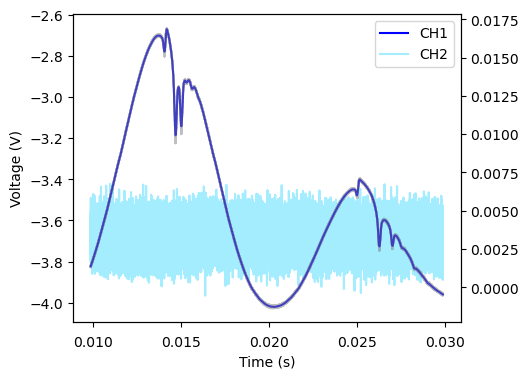

In [247]:
t, y, y_smooth,f, f_smooth = load_and_smooth(24)

t_min = -1
t_max = 1

mask = (t >= t_min) & (t <= t_max)
t_sel = t[mask]
y_sel = y_smooth[mask]
raw_sel = y[mask]
f_sel = f[mask]
# 선택구간에서만 baseline 피팅
coef = np.polyfit(t_sel, raw_sel, deg=1)
baseline_sel = np.polyval(coef, t_sel)
# baseline 제거
raw_corr = raw_sel - baseline_sel
y_corr = y_sel - baseline_sel
# 플롯
'''
plt.plot(t_sel, y_corr, color='blue')
plt.plot(t_sel, raw_corr, color='grey', alpha=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.plot(t_sel,f_sel*0.005, color ="#89c18d" ) #print((f_smooth[-1]-f_smooth[0])/(t[-1]-t[0]))
'''
fig, ax1 = plt.subplots(figsize=(5,4))
# x축 눈금 간격 널널하게
ax1.xaxis.set_major_locator(MultipleLocator(0.005))
ax1.tick_params(axis='x', labelsize=10, pad=6) #pad는 축과 숫자 간격

# ax1
ax1.plot(t_sel, y_sel, color='blue', label ="CH1")
ax1.plot(t_sel, raw_sel, color='grey', alpha=0.5, label="_nolegend_")

# ax2
ax2 = ax1.twinx()
ax2.set_zorder(ax1.get_zorder() - 1)
ax1.patch.set_alpha(0)

ax2.plot(t_sel,f_sel*0.5, color ="#ffffff" , lw = 0.1, label="_nolegend_")
ax2.plot(t_sel,f_sel*0.2,  color ="#a3edff", label ="CH2")
#ax2.plot(t_sel,f_sel*0.01, color ="#ffffff" , lw = 0.1, label="_nolegend_")

# 🔥 label 있는 것만 legend
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend([l for l in lines if l.get_label() != "_nolegend_"],
           [l.get_label() for l in lines if l.get_label() != "_nolegend_"],
           loc='upper right')
# 오른쪽 y축은 테두리만 남기고 눈금/라벨 제거
#ax2.set_yticks([])
#ax2.set_ylabel('')
#ax2.tick_params(right=False)

ax1.spines['left'].set_visible(True)
ax1.set_ylabel("Voltage (V)")
ax1.set_xlabel("Time (s)")

Text(0.5, 0, 'Time (s)')

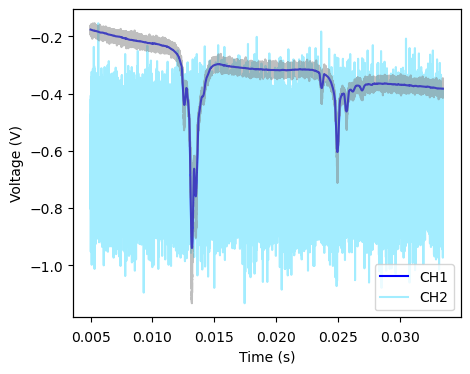

In [252]:
t, y, y_smooth,f, f_smooth = load_and_smooth(21)

t_min = 0.005
t_max = 0.0335

mask = (t >= t_min) & (t <= t_max)
t_sel = t[mask]
y_sel = y_smooth[mask]
raw_sel = y[mask]
f_sel = f[mask]

# 플롯
'''
plt.plot(t_sel, y_corr, color='blue')
plt.plot(t_sel, raw_corr, color='grey', alpha=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.plot(t_sel,f_sel*0.005, color ="#89c18d" ) #print((f_smooth[-1]-f_smooth[0])/(t[-1]-t[0]))
'''
fig, ax1 = plt.subplots(figsize=(5,4))
# x축 눈금 간격 널널하게
ax1.xaxis.set_major_locator(MultipleLocator(0.005))
ax1.tick_params(axis='x', labelsize=10, pad=6) #pad는 축과 숫자 간격

# ax1
ax1.plot(t_sel, y_sel, color='blue', label ="CH1")
ax1.plot(t_sel, raw_sel, color='grey', alpha=0.5, label="_nolegend_")

# ax2
ax2 = ax1.twinx()
ax2.set_zorder(ax1.get_zorder() - 1)
ax1.patch.set_alpha(0)

#x2.plot(t_sel,f_sel*0.5, color ="#ffffff" , lw = 0.1, label="_nolegend_")
ax2.plot(t_sel,f_sel*0.2,  color ="#a3edff", label ="CH2")
#ax2.plot(t_sel,f_sel*0.01, color ="#ffffff" , lw = 0.1, label="_nolegend_")

# 🔥 label 있는 것만 legend
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend([l for l in lines if l.get_label() != "_nolegend_"],
           [l.get_label() for l in lines if l.get_label() != "_nolegend_"],
           loc='lower right')
# 오른쪽 y축은 테두리만 남기고 눈금/라벨 제거
ax2.set_yticks([])
ax2.set_ylabel('')
ax2.tick_params(right=False)

ax1.spines['left'].set_visible(True)
ax1.set_ylabel("Voltage (V)")
ax1.set_xlabel("Time (s)")

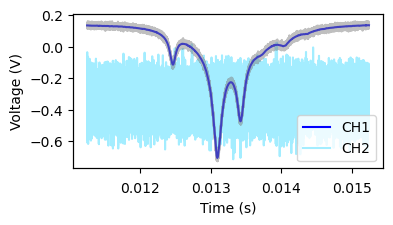

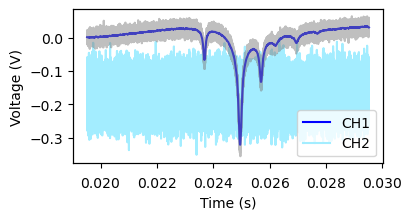

In [253]:
for k in [20,22]:
    t, y, y_smooth,f, f_smooth = load_and_smooth(k)

    t_min = -1
    t_max = 1



    mask = (t >= t_min) & (t <= t_max)

    t_sel = t[mask]
    y_sel = y_smooth[mask]
    raw_sel = y[mask]
    f_sel = f[mask]
# 선택구간에서만 baseline 피팅
    coef = np.polyfit(t_sel, raw_sel, deg=1)
    baseline_sel = np.polyval(coef, t_sel)

# baseline 제거
    raw_corr = raw_sel - baseline_sel
    y_corr = y_sel - baseline_sel

    fig, ax1 = plt.subplots(figsize=(4,2))
# x축 눈금 간격 널널하게
    if k ==20:
        ax1.xaxis.set_major_locator(MultipleLocator(0.001))
    elif k==22:
        ax1.xaxis.set_major_locator(MultipleLocator(0.002))
    else:
        continue
    ax1.tick_params(axis='x', labelsize=10, pad=6) #pad는 축과 숫자 간격

# ax1
    ax1.plot(t_sel, y_corr, color='blue', label ="CH1")
    ax1.plot(t_sel, raw_corr, color='grey', alpha=0.5, label="_nolegend_")

# ax2
    ax2 = ax1.twinx()
    ax2.set_zorder(ax1.get_zorder() - 1)
    ax1.patch.set_alpha(0)

    ax2.plot(t_sel,f_sel*0.6, color ="#ffffff" , lw = 0.1, label="_nolegend_")
    ax2.plot(t_sel,f_sel*0.5,  color ="#a3edff", label ="CH2")
    #ax2.plot(t_sel,f_sel*0.1, color ="#ffffff" , lw = 0.1, label="_nolegend_")

# 🔥 label 있는 것만 legend
    lines = ax1.get_lines() + ax2.get_lines()
    ax1.legend([l for l in lines if l.get_label() != "_nolegend_"],
           [l.get_label() for l in lines if l.get_label() != "_nolegend_"],
           loc='lower right')

# 오른쪽 y축은 테두리만 남기고 눈금/라벨 제거
    ax2.set_yticks([])
    ax2.set_ylabel('')
    ax2.tick_params(right=False)

# 왼쪽 y축은 정상 유지
    ax1.spines['left'].set_visible(True)


    ax1.set_ylabel("Voltage (V)")
    ax1.set_xlabel("Time (s)")

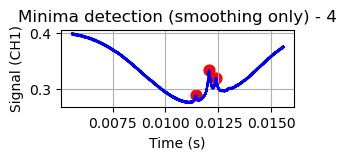

In [287]:
def plot_smoothed_with_peaks4(i):
    window_length=7
    polyorder=3
    prom_scale=0.2
    dist_scale=250
    # ----------------------------
    # 1) Load data
    # ----------------------------
    t = Time[i]
    y = CH1[i]
    f = CH2[i]

    # ----------------------------
    # 2) Smoothing
    # ----------------------------
    if window_length % 2 == 0:
        window_length += 1

    y_s = savgol_filter(y, window_length, polyorder)
    f_s = savgol_filter(f, window_length, polyorder)

    # ----------------------------
    # 3) Minima detection
    # ----------------------------
    prom = np.std(y_s) * prom_scale
    dist = len(y) // dist_scale

    peaks, _ = find_peaks(y_s, prominence=prom, distance=dist)

    # ----------------------------
    # 4) Plot
    # ----------------------------
    plt.figure(figsize=(3,1))
    plt.plot(t, y, color='gray', alpha=0.4, label="Raw")
    plt.plot(t, y_s, color='blue', label=f"Smoothed (win={window_length})")
    plt.scatter(t[peaks], y_s[peaks], c='red', s=60, label="Detected minima")
    plt.title(f"Minima detection (smoothing only) - {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("Signal (CH1)")
    plt.grid()
    #plt.legend()
    plt.show()

    for idx in peaks:
        #print(f"{t[idx]:.6f}, {y_s[idx]:.6f}, {y[idx]:.6f}, {f_s[idx]:.6f}, {f[idx]:.6f}")

        # save into dynamically created lists
        globals()[f"data{i}_T"].append(float(t[idx]))
        globals()[f"data{i}_1"].append(float(y_s[idx]))
        globals()[f"data{i}_y"].append(float(y[idx]))
        globals()[f"data{i}_2"].append(float(f_s[idx]))
        globals()[f"data{i}_f"].append(float(f[idx]))

   
for i in [4]:
    plot_smoothed_with_peaks4(i) # 약한 smoothing → 작은 peak 민감하게 잡음


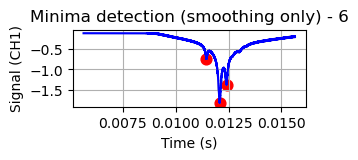

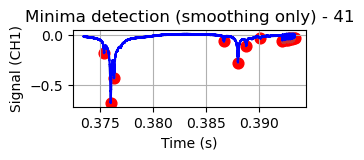

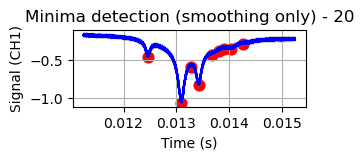

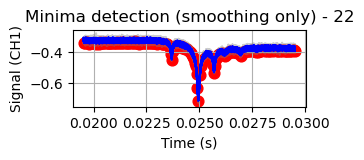

In [288]:
def plot_smoothed_with_peaks3(i):
    window_length=7
    polyorder=3
    prom_scale=0.2
    dist_scale=250
    # ----------------------------
    # 1) Load data
    # ----------------------------
    t = Time[i]
    y = CH1[i]
    f = CH2[i]

    # ----------------------------
    # 2) Smoothing
    # ----------------------------
    if window_length % 2 == 0:
        window_length += 1

    y_s = savgol_filter(y, window_length, polyorder)
    f_s = savgol_filter(f, window_length, polyorder)

    # ----------------------------
    # 3) Minima detection
    # ----------------------------
    prom = np.std(y_s) * prom_scale
    dist = len(y) // dist_scale

    peaks, _ = find_peaks(-y_s, prominence=prom, distance=dist)

    # ----------------------------
    # 4) Plot
    # ----------------------------
    plt.figure(figsize=(3,1))
    plt.plot(t, y, color='gray', alpha=0.4, label="Raw")
    plt.plot(t, y_s, color='blue', label=f"Smoothed (win={window_length})")
    plt.scatter(t[peaks], y_s[peaks], c='red', s=60, label="Detected minima")
    plt.title(f"Minima detection (smoothing only) - {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("Signal (CH1)")
    plt.grid()
    #plt.legend()
    plt.show()

    for idx in peaks:
        #print(f"{t[idx]:.6f}, {y_s[idx]:.6f}, {y[idx]:.6f}, {f_s[idx]:.6f}, {f[idx]:.6f}")

        # save into dynamically created lists
        globals()[f"data{i}_T"].append(float(t[idx]))
        globals()[f"data{i}_1"].append(float(y_s[idx]))
        globals()[f"data{i}_y"].append(float(y[idx]))
        globals()[f"data{i}_2"].append(float(f_s[idx]))
        globals()[f"data{i}_f"].append(float(f[idx]))

   
for i in [6,41,20,22]:
    plot_smoothed_with_peaks3(i) # 약한 smoothing → 작은 peak 민감하게 잡음



In [ ]:
for i in [4,6,20,22]:
    print(f"data{i}_T = {globals()[f'data{i}_T']}")
    print(f"data{i}_1 = {globals()[f'data{i}_1']}")
    #print(f"data{i}_y = {globals()[f'data{i}_y']}")
    #print(f"data{i}_2 = {globals()[f'data{i}_2']}")
    #print(f"data{i}_f = {globals()[f'data{i}_f']}")
    print()

data4_T = [0.0120692, 0.0123972, 0.0114402, 0.0126802, 0.0130316]
data4_1 = [0.3341294285714288, 0.3202038571428574, 0.2884459523809526, 0.2970975120096744, 0.3008597511899701]

data6_T = [0.0114508, 0.012078, 0.0124027, 0.01266, 0.0130008, 0.01333]
data6_1 = [-0.7364095714285721, -1.8329223809523822, -1.3753066666666678, -0.6841601250321219, -0.5659081251481841, -0.4291233702792272]

data41_T = [0.3753528, 0.3759826, 0.3763094, 0.3866942, 0.3880272, 0.3888198, 0.3901418, 0.3922194, 0.392399, 0.3925332, 0.392653, 0.3927662, 0.3928738, 0.3929648, 0.3930606, 0.3931696, 0.393292, 0.3933798, 0.3753528, 0.3759826, 0.3763094, 0.3866942, 0.3880272, 0.3888198, 0.3901418, 0.3922194, 0.392399, 0.3925332, 0.392653, 0.3927662, 0.3928738, 0.3929648, 0.3930606, 0.3931696, 0.393292, 0.3933798, 0.3753528, 0.3759826, 0.3763094, 0.3866942, 0.3880272, 0.3888198, 0.3901418, 0.3922194, 0.392399, 0.3925332, 0.392653, 0.3927662, 0.3928738, 0.3929648, 0.3930606, 0.3931696, 0.393292, 0.3933798, 0.3753528, 0.37

In [290]:
def find_min_in_range(t, y_corr, f_smooth, f, t_min, t_max):
    # 구간 마스크
    mask = (t >= t_min) & (t <= t_max)

    t_sel = t[mask]
    y_sel = y_corr[mask]
    f_sel = f_smooth[mask]
    #ch1_sel = y[mask] #original
    ch2_sel = f[mask] #original
    # 구간에 데이터가 없을 때
    if len(y_sel) == 0:
        print("⚠ 선택한 구간에 데이터가 없습니다.")
        return None, None

    # 최대값 찾기
    idx = np.argmin(y_sel)
    x_min = t_sel[idx]
    y_min = y_sel[idx]
    f_min = f_sel[idx]
    #ch1_min = ch1_sel[idx]
    ch2_min = ch2_sel[idx]
    return x_min, y_min, f_min, ch2_min
def find_max_in_range(t, y_corr, f_smooth, f, t_min, t_max):
    # 구간 마스크
    mask = (t >= t_min) & (t <= t_max)

    t_sel = t[mask]
    y_sel = y_corr[mask]
    f_sel = f_smooth[mask]
    #ch1_sel = y[mask] #original
    ch2_sel = f[mask] #original
    # 구간에 데이터가 없을 때
    if len(y_sel) == 0:
        print("⚠ 선택한 구간에 데이터가 없습니다.")
        return None, None

    # 최대값 찾기
    idx = np.argmax(y_sel)
    x_min = t_sel[idx]
    y_min = y_sel[idx]
    f_min = f_sel[idx]
    #ch1_min = ch1_sel[idx]
    ch2_min = ch2_sel[idx]
    return x_min, y_min, f_min, ch2_min


Min point: 0.0249527 -0.6930782331094751


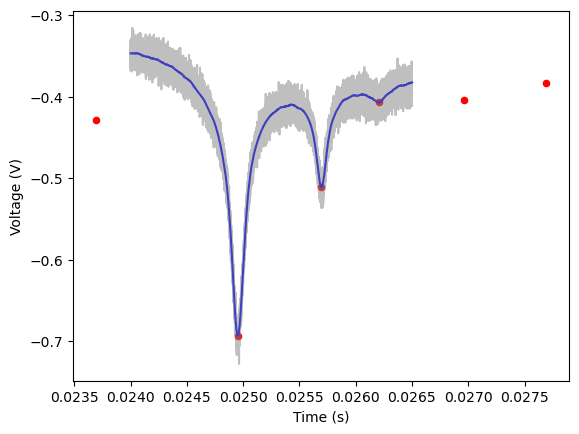

In [403]:
k =22
t, y, y_smooth,f, f_smooth = load_and_smooth(k)
t_min = 0.024
t_max = 0.0265
x_min, y_min, f_min, ch2_min = find_min_in_range(t,y_smooth, f_smooth,f, t_min, t_max)
x_max, y_max, f_max, ch2_max = find_max_in_range(t,y_smooth, f_smooth,f, t_min, t_max)
print("Min point:", x_min, y_min)
#print("Max point:", x_max, y_max)

mask = (t >= t_min) & (t <= t_max)
t_sel = t[mask]
y_sel = y_smooth[mask]
raw_sel = y[mask]
f_sel = f[mask]

plt.plot(figsize=(5,3))
plt.plot(t_sel, y_sel, color='blue')
plt.plot(t_sel, raw_sel, color='grey', alpha=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
#plt.plot(t_sel,f_sel*0.005, color ="#89c18d" ) #print((f_smooth[-1]-f_smooth[0])/(t[-1]-t[0]))
data4_T = [ 0.0120692, 0.0123972,   0.0114402,0.0126802, 0.0130316]
data4_1 = [ 0.3341294285714288, 0.3202038571428574, 0.2884459523809526, 0.2970975120096744, 0.3008597511899701]

data6_T = [0.0114508, 0.012078, 0.0124027, 0.01266,0.0130008, 0.01333]
data6_1 = [-0.7364095714285721, -1.8329223809523822, -1.3753066666666678, -0.6841601250321219, -0.5659081251481841,-0.4291233702792272]

data20_T = [0.01245964, 0.01309224,  0.01341884, 0.0136804, 0.01402668, 0.01432912]
data20_1 = [-0.4589983333333337, -1.0631419047619057, -0.8269374761904769,-0.40874086697864315,  -0.3474425384900609, -0.27536046143029125]

data22_T = [0.0236885 , 0.0249527 , 0.0256933 , 0.0262049, 0.0269579, 0.0276952]
data22_1 = [-0.427862235597662, -0.6930782331094751 ,-0.5108693442419855, -0.4068403981373117, -0.40335179326271237,  -0.3824822348285126]
plt.scatter(globals()[f"data{k}_T"],globals()[f"data{k}_1"],marker='.',s=80,color='red')    


In [440]:
t, y, y_smooth,f, f_smooth = load_and_smooth(22)

t_min = 0
t_max = 0.1



mask = (t >= t_min) & (t <= t_max)

t_sel = t[mask]
y_sel = y_smooth[mask]
raw_sel = y[mask]
f_sel = f_smooth[mask]



# Lorentzian dip model
def lorentzian_dip(x, A, x0, gamma, C):
    return C - A * (gamma**2 / ((x - x0)**2 + gamma**2))

# 초기값 설정 (중요)
A0 = np.max(y_sel) - np.min(y_sel)
x0_0 = t_sel[np.argmin(y_sel)]
gamma0 = (t_sel[-1] - t_sel[0]) / 10
C0 = np.max(y_sel)

p0 = [A0, x0_0, gamma0, C0]

# fitting
popt, pcov = curve_fit(lorentzian_dip, t_sel, y_sel, p0=p0)

A_fit, x0_fit, gamma_fit, C_fit = popt
A_fit, x0_fit, gamma_fit, C_fit = popt

print(f"A = {A_fit}")
print(f"x0 (center) = {x0_fit}")
print(f"gamma (HWHM) = {gamma_fit}")
print(f"C (baseline) = {C_fit}")

print("--error--")
perr = np.sqrt(np.diag(pcov))

print(f"x0 = {x0_fit} ± {perr[1]}")
print(f"gamma = {gamma_fit} ± {perr[2]}")

A = 0.28332476703174736
x0 (center) = 0.024958520533768062
gamma (HWHM) = 0.0001410626835083159
C (baseline) = -0.35620549437117127
--error--
x0 = 0.024958520533768062 ± 4.59794227630165e-07
gamma = 0.0001410626835083159 ± 6.804438595242047e-07


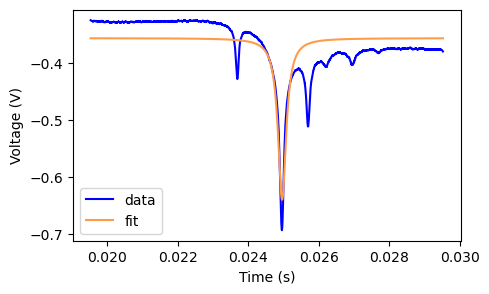

'\n전체범위\nA = 0.28332476703174736\nx0 (center) = 0.024958520533768062\ngamma (HWHM) = 0.0001410626835083159\nC (baseline) = -0.35620549437117127\n--error--\nx0 = 0.024958520533768062 ± 4.59794227630165e-07\ngamma = 0.0001410626835083159 ± 6.804438595242047e-07\n'

In [442]:
plt.figure(figsize=(5,3))
plt.plot(t_sel, y_sel, label='data', color = 'blue')
plt.plot(t_sel, lorentzian_dip(t_sel, *popt), label='fit', color = "#ff9c4a")
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.show()
'''
t_min = 0.024
t_max = 0.0255
A = 0.30376949495632516
x0 (center) = 0.02495486352533178
gamma (HWHM) = 0.00010427542908170136
C (baseline) = -0.366530175000115
--error--
x0 = 0.02495486352533178 ± 2.0925421045766032e-07
gamma = 0.00010427542908170136 ± 3.730611496805103e-07'''

'''
t_min = 0.024
t_max = 0.0265
A = 0.2955505659428182
x0 (center) = 0.0249543696533437
gamma (HWHM) = 8.030631543462968e-05
C (baseline) = -0.3934074012342037
--error--
x0 = 0.0249543696533437 ± 3.2222128186438365e-07
gamma = 8.030631543462968e-05 ± 5.060731296039218e-07'''

'''
전체범위
A = 0.28332476703174736
x0 (center) = 0.024958520533768062
gamma (HWHM) = 0.0001410626835083159
C (baseline) = -0.35620549437117127
--error--
x0 = 0.024958520533768062 ± 4.59794227630165e-07
gamma = 0.0001410626835083159 ± 6.804438595242047e-07
'''

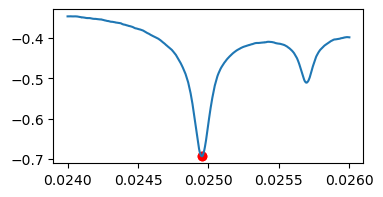

Peak 1:
  x0 = 0.024953134601662017
  gamma = 0.00010491203620046663
  A = 0.3082181810475587
Peak 2:
  x0 = 0.025692209728100976
  gamma = 0.0001520875679399097
  A = 0.11956265947512064
Baseline C = -0.357599917603384


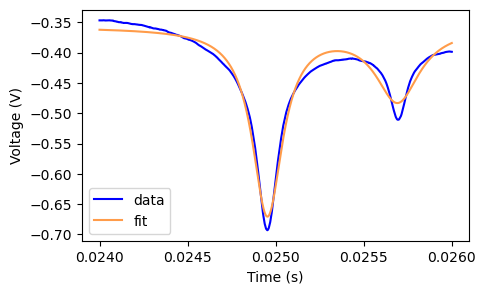

In [447]:
t, y, y_smooth,f, f_smooth = load_and_smooth(22)

t_min = 0.024
t_max = 0.026
mask = (t >= t_min) & (t <= t_max)
t_sel = t[mask]
y_sel = y_smooth[mask]
raw_sel = y[mask]
f_sel = f_smooth[mask]


def multi_lorentzian(x, *params):
    C = params[-1]  # 마지막 파라미터를 baseline으로
    y = np.zeros_like(x)

    for i in range(0, len(params)-1, 3):
        A, x0, gamma = params[i:i+3]
        y -= A * (gamma**2 / ((x - x0)**2 + gamma**2))

    return y + C

idx1 = np.argmin(y_sel)

# 두 번째 dip (대충 오른쪽에서 찾기)
idx2 = idx1 + np.argmin(y_sel[idx1+20:]) + 20

p0 = [
    0.3, t_sel[idx1], 0.0002,   # 큰 dip
    0.15, t_sel[idx2], 0.0002,  # 작은 dip
    np.mean(y_sel)              # baseline
]
#디버깅?
plt.figure(figsize=(4,2))
plt.plot(t_sel, y_sel)
plt.scatter([p0[1], p0[4]], [y_sel[idx1], y_sel[idx2]], color='red')
plt.show()

popt, pcov = curve_fit(
    multi_lorentzian,
    t_sel,
    y_sel,
    p0=p0,
    bounds=(
        [0, t_sel.min(), 0,   0, t_sel.min(), 0,   -np.inf],
        [1, t_sel.max(), 0.01, 1, t_sel.max(), 0.01, np.inf]
    )
)

n_peaks = (len(popt) - 1) // 3

for i in range(n_peaks):
    A = popt[3*i]
    x0 = popt[3*i + 1]
    gamma = popt[3*i + 2]

    print(f"Peak {i+1}:")
    print(f"  x0 = {x0}")
    print(f"  gamma = {gamma}")
    print(f"  A = {A}")

print(f"Baseline C = {popt[-1]}")
plt.figure(figsize=(5,3))
plt.gca().xaxis.set_major_locator(MultipleLocator(0.0005))
plt.plot(t_sel, y_sel, label='data', color = 'blue')
plt.plot(t_sel, multi_lorentzian(t_sel, *popt), label='fit', color = "#ff9c4a")
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.show()

In [ ]:
'''
t_min = 0.024
t_max = 0.0265
Peak 1:
  x0 = 0.024953222059553446
  gamma = 9.365788360651475e-05
  A = 0.30614276550776887
Peak 2:
  x0 = 0.025695320828946662
  gamma = 0.0001556274433063361
  A = 0.1060211438068443
Baseline C = -0.368860712228141
'''

'''
t_min = 0.024
t_max = 0.026
Peak 1:
  x0 = 0.024953134601662017
  gamma = 0.00010491203620046663
  A = 0.3082181810475587
Peak 2:
  x0 = 0.025692209728100976
  gamma = 0.0001520875679399097
  A = 0.11956265947512064
Baseline C = -0.357599917603384'''

't_min = 0.024\nt_max = 0.0265\nPeak 1:\n  x0 = 0.024953222059553446\n  gamma = 9.365788360651475e-05\n  A = 0.30614276550776887\nPeak 2:\n  x0 = 0.025695320828946662\n  gamma = 0.0001556274433063361\n  A = 0.1060211438068443\nBaseline C = -0.368860712228141\n'